In [1]:
%pwd # Set the Working directory

'C:\\Users\\Antonio\\anaconda_projects\\ef4ef301-aa4b-456a-8296-60c9e31af76d'

In [34]:
import numpy as np #numerical library

##  2. Some stochastic process, with states labelled A,B,C,D,E, has the following transition matrix ##

### (a) Knowing that this is a stochastic matrix, calculate the value of x. Explain in your own words what property of stochastic matrices you’re using and why this property must hold mathematically. ###

In [3]:
#Known probabilities in ROW C (State 3 = Third Row) 

sumrow3 = 0.16 + 0.16 + 0.22 + 0.26 #sum of all known entries 

#Get x 
x = 1 - sumrow3

#Print (decimal rounded)
print("Value of x", round(x,2))


Value of x 0.2


Explanation: In a stochastic matrix, every single row illustrates the ways that the processes can move from one state to the other. The probabilities of each row must also equal to 1. 

### (b) Assuming the initial distribution of states is A (13%), B (24%), C (32%), D (28%), and E (3%) calculate the distribution of states after 3 generations? Show your intermediate calculations for the distribution after 1 and 2 generations. Explain what you observe about how the distribution evolves and why this makes sense given the structure of P. ###

In [4]:
# define transition matrix P

P = np.array([[0.21, 0.07, 0.15, 0.11, 0.46], 
              [0.0, 1.0, 0.0, 0.0, 0.0], 
              [0.16, 0.16, 0.22, 0.20, 0.26],
              [0.0, 0.0, 0.0, 1.0, 0.0], 
              [0.21, 0.27, 0.18, 0.24, 0.10]])

#initial distribution and distributions after 1 2 and 3 generations 

pi0 = np.array([0.13, 0.24, 0.32, 0.28, 0.03]) 

pi1 = np.dot(pi0, P)  # 1 
pi2 = np.dot(pi1, P)  # 2 
pi3 = np.dot(pi2, P)  # 3 

print("Distribution after 1 generation:", pi1) 
print("Distribution after 2 generations:", pi2) 
print("Distribution after 3 generations:", pi3)

Distribution after 1 generation: [0.0848 0.3084 0.0953 0.3655 0.146 ]
Distribution after 2 generations: [0.063716 0.369004 0.059966 0.428928 0.078386]
Distribution after 3 generations: [0.03943598 0.4042229  0.0368594  0.4667426  0.05273912]


Explanation:
Probabilies dain from transient A/C/E, into absrorbers B and D. This occurs because B and D are absorbing so once entered, the chain stays forever  (also known as "Roach Motel" effect) so itirations accumulare probability in B and D as transients emtpy.

### (c) Rewrite P in the canonical form, clearly identifying R and Q. ###

In [23]:
P_Canonical_Form = np.array([
    [1.00, 0.00, 0.00, 0.00, 0.00],
    [0.00, 1.00, 0.00, 0.00, 0.00],
    [0.07, 0.11, 0.21, 0.15, 0.46],
    [0.16, 0.20, 0.16, 0.22, 0.26],
    [0.27, 0.24, 0.21, 0.18, 0.10]])

print("Matrix\n", P_Canonical_Form)


#R
R = np.array([
    [0.07,0.11],
    [0.16, 0.20],
    [0.27, 0.24]
])


#Q
Q = np.array([
    [0.21,0.15,0.46],
    [0.16,0.22,0.26],
    [0.21,0.18,0.10]
])

#Print 
print("R matrix:")
print (R)

print("\nQ matrix:")
print(Q)

Matrix
 [[1.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.  ]
 [0.07 0.11 0.21 0.15 0.46]
 [0.16 0.2  0.16 0.22 0.26]
 [0.27 0.24 0.21 0.18 0.1 ]]
R matrix:
[[0.07 0.11]
 [0.16 0.2 ]
 [0.27 0.24]]

Q matrix:
[[0.21 0.15 0.46]
 [0.16 0.22 0.26]
 [0.21 0.18 0.1 ]]


### (d) For each state, i, calculate the mean number of times that the process is in a transient state j, given it started in i. Write out the formula you’ll use and explain each component. ###

Formula for fundamental matrix: 
$$N = (I - Q)^{-1}$$


Components:

- N = fundamental matrix
- I = identity matrix same as Q
- Q = matrix of transition probabilities from transient state to other transient state
- (I-Q)-1: the inverse of the matrix I-Q

- Nij = forecasted numbers of visits to transient state j (starting in i before it absorbs) 

In [6]:
#Q transient to transient
Q = np.array([[0.21,0.15,0.46],
              [0.16, 0.22,0.26],
              [0.21,0.18,0.10]])

#I 
I = np.array([
    [1.0,0.0,0.0],
    [0.0,1.0,0.0],
    [0.0,0.0,1.0]
])

N = np.linalg.inv(I - Q)

print("Fundamental Matrix N:")
print(np.round(N,3))

Fundamental Matrix N:
[[1.641 0.546 0.996]
 [0.497 1.539 0.699]
 [0.482 0.435 1.483]]


### (e) For each state i, find the mean number of transitions before the process hits an absorbing state, given that the process starts in a transient state i. Write out the formula you’ll use and explain each component ###

Formula:

$$M = N\mathbf{1} = (I - Q)^{-1}\mathbf{1}$$

Components:
- Q: the trnasient to transient block in the canonical form
- I: the identity matrix
- N: the fundamental matrix (written as $N = (I - Q)^{-1}$), where Nij is the forecasted number or visits to transient state j starting from transient state i before absorbsion.
- 1: a column of vectors
- M(t): the time for the absorbion vector, which sums the rows of N

In [7]:
# Q - Transient to transient matrix
Q = np.array([[0.21,0.15,0.46],
              [0.16,0.22,0.26],
              [0.21,0.18,0.10]])
# I - Identity Matrix 
I = np.array([[1.0,0.0,0.0],
              [0.0,1.0,0.0],
              [0.0,0.0,1.0]])

# Fundamental Matrix
N = np.linalg.inv(I - Q)

# Vector of ones for each transient state 
ones = np.array([1,1,1])

# Avarage nr of transitions before absorption
M = np.dot(N, ones)

#print
print("Mean number of transitions before absorptions from A,C,E:")
print(np.round(M,3))

Mean number of transitions before absorptions from A,C,E:
[3.183 2.735 2.401]


The above results illustrate that if a process starts in State A it would require 3.183 steps before hitting absorption. Conversely, it seems that State E is a the most volatile state as it would need only 2.401 steps to reach an absorbing state. This is due to its mean number being the smallest. 

### (f) For each state i, find the probability of ending in each of the absorbing states. Write out the formula you’ll use and explain each component. ###

Formula:

$$B = N \times R = (I - Q)^{-1} R$$

- B: Absorption probability matrix + each row of B needs to sum up to 1 and end in some absorbing state.
- N: Fundamental matrix.
- R: Transient to absorbing matrix (probability by moving one step from transient state to absorbing state).
- I-Q: this is the identinty matrix minus the transient to transient matrix (I has the same size as Q).

In [8]:
N = np.array ([[1.641,0.546,0.996],
               [0.497,1.539,0.699],
               [0.482,0.435,1.483]])

R = np.array ([[0.07,0.11],
               [0.16,0.20],
               [0.27,0.24]])

#Calculate B
B = np.dot(N,R)

print("Absorption Probabilities:")
print(np.round(B,3))

Absorption Probabilities:
[[0.471 0.529]
 [0.47  0.53 ]
 [0.504 0.496]]


The matrix presented above illustrates the probabilities of finishing in each absorbing state (B / D), when starting from a transient state(A / C / E).

In [9]:
#Verification - as each row must sum to 1

row_A = 0.471+0.529
row_C = 0.47+0.53
row_E =0.504+0.496

print(f"Row A Total: {row_A}")
print(f"Row C Total: {row_C}")
print(f"Row E Total: {row_E}")

Row A Total: 1.0
Row C Total: 1.0
Row E Total: 1.0


## 3. Consider the generalised random walk: ##


dS = a(x, t)dt + b(x, t)dW
where a(x, t) = (1/α) sin(x) cos(t) and b(x, t) = 1/β. Take your student number, set α =
(first 3 digits)/100, β = (last 3 digits)/100. 

### (a) State your student number, α, and β. Before any coding, explain what you expect a single walk trajectory will look like for 2500 steps; e.g. will it trend upward/downward?  will it oscillate? Justify your reasoning based on the mathematical form of a(x, t) and b(x, t). ###

In [10]:
## Student Number: 3541011

alpha = 354 /100
beta = 11 / 100  #ignoring the first digit as it is a 0

print(f"Alpha: {alpha}")
print(f"Bata: {beta}")
print(f"Noise level (1/beta): {round(1/beta,2)}") #round and only 2 digits 


Alpha: 3.54
Bata: 0.11
Noise level (1/beta): 9.09


The trajectory is forecasted to oscillate instead of a steady upward or downward trend. The Beta value is also small meaning that the noise level is high and will generate a volatile path over the 2500 proposed steps.

### (b) This code runs but gives incorrect results. Explain why this code is incorrect and propose a fix for the bug. ###

In [11]:
N = 2500 #number of steps 
dt = 0.01 #step size

alpha = 3.54
beta = 0.11

x = 0
for i in range (N) :
    t = i*dt
    x = x + (1/alpha)*np.sin(x)*np.cos(t)* dt + (1/beta)*np.random.normal(0,1)

print(x)

305.00652603763535


While the above code runs, it gives an incorrect result. The random term is missing the $\sqrt{dt}$ factor, so the noise is too large and does not represent $dW∼N(0,dt)$.

In [12]:
#Revised Code#

x = 0
for i in range (N) :
    t = i*dt
    x = x + (1/alpha)*np.sin(x)*np.cos(t)* dt \
            + (1/beta)*np.sqrt(dt)*np.random.normal(0, 1)

print(x)

24.95930636225092


The above revised code is correct as it scales the random step by $\sqrt{dt}$ factor.

### (c) Implement the walk with dt = 0.01 (you can use the corrected code from the previous part). Plot THREE different realisations of this walk on the same axes. Explain why they differ despite using the same equation. ###

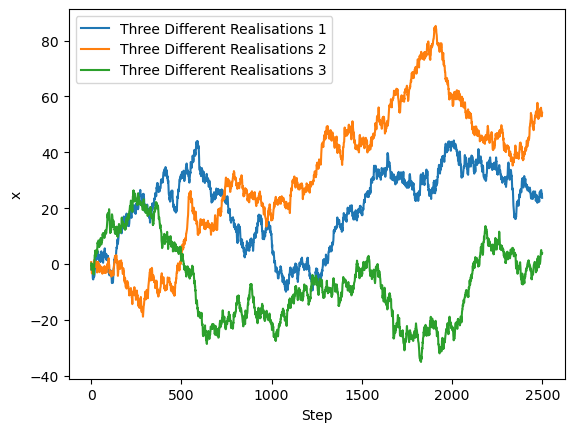

In [25]:
import matplotlib.pyplot as plt  #library needed for plot

#Parameters 
N = 2500
dt = 0.01

#Loop 3 times below 
for j in range (3):
    x = 0
    xs = []

# I added \ to ensure full code is clear on the PDF output. Will
# also do the same in other code lines where the code is a bit longer.
    
    for i in range (N):
        t = i * dt
        x = x + (1/alpha)*np.sin(x)*np.cos(t)* dt \
        + (1/beta)*np.sqrt(dt)*np.random.normal(0,1)
        xs.append(x)

    plt.plot(xs, label=f"Three Different Realisations {j+1}")

plt.xlabel("Step")
plt.ylabel("x")
plt.legend()
plt.show()
        

The three paths above are different every time I run the code because the noise term is random. This means that the computer selects a new set of random digits for every walk leading to an unpredictable and different routes every time the code is ran.

### (d) Calculate the mean position after 2500 steps by averaging over 1000 independent walks. Repeat this for dt = 0.05, 0.1, 0.2, 0.4. Display your results and explain why they are or are not what you expected.  ###

In [14]:
time_steps = [0.01 , 0.05, 0.1, 0.2, 0.4]  #0.1 from previous question
number_of_steps = 2500
number_of_walks = 1000

for dt in time_steps:
    final_positions = []

    for walk in range(number_of_walks):
        x = 0
        for step in range(number_of_steps):
            t = step*dt
            x = x + (1/alpha)*np.sin(x)*np.cos(t)* dt \
            + (1/beta)*np.sqrt(dt)*np.random.normal(0,1)
        final_positions.append(x)
    mean_position = np.mean(final_positions)
    print("dt =", "Mean Positions after 2500 steps =", mean_position)


dt = Mean Positions after 2500 steps = 0.6592409907340746
dt = Mean Positions after 2500 steps = -2.311485830931865
dt = Mean Positions after 2500 steps = -2.3299980233317865
dt = Mean Positions after 2500 steps = -3.624730512304471
dt = Mean Positions after 2500 steps = -17.773195441165708


In the above output it is illustrated the mean position after 2500 steps with different dt (different sizes of the steps taken). Analysing the smallest step size the mean is very close to 0 (roughly 0.66 in the above code) which is something I expected because when no drift is taken into account, the steps should eventually balance out over the 2500 walks (so being close to 0). When larger dt are taken into consideration, the mean is positioned further away from the 0 ( up to -18). This might mean that having a higher time step can reduce the accuracy of the simulation and push the mean away from the 0, instead of fluctuating around it. 

### (e) For dt=0.01, create a histogram of final positions (after 2500 steps) for 5000 walks. Is it normally distributed? Use a statistical test and report relevant statistics and conclusions. ###

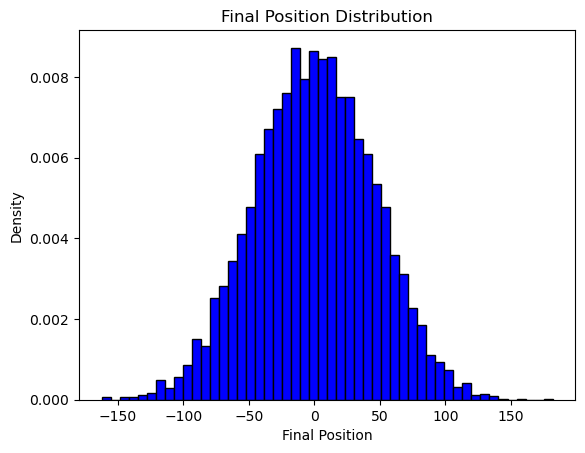

Shapiro Wilk Test = 0.9997
P-Value = 0.7204
Conclusion: The distribution appears normally distributed.


In [15]:
from scipy import stats

#Parameters
N = 2500
dt = 0.01
walks = 5000
alpha = 3.54
beta = 0.11

#Do 5000 walks 
x = np.zeros(walks)
for i in range(N):
    t = i * dt
    x = x + (1/alpha)*np.sin(x)*np.cos(t)* dt \
    + (1/beta)*np.sqrt(dt)*np.random.normal(0,1, size=walks)

#Plot and Histogram required
plt.hist(x, bins =50, density=True, color="blue", edgecolor="black")
plt.title("Final Position Distribution")
plt.xlabel("Final Position")
plt.ylabel("Density")
plt.show()

#Shapiro Wilk Test
statistic, p_value = stats.shapiro(x)
print(f"Shapiro Wilk Test = {statistic:.4f}")
print(f"P-Value = {p_value:.4f}")
if p_value > 0.05:
    print("Conclusion: The distribution appears normally distributed.")
else:
    print("Coclusion: The distribution is not normally distributed.")


THe above Shapiro Wilk Test illustrates that the data is normally distributed, as per the output of the code above. Test's result is close to 1.0 (output:0.9997) which indicates that the distribution of the data aligns closely with a theorethical normal distribution. Moreover, the current p-value of 0.74 is above the general threshold of 0.05 so I fail to reject the H0 (null hypothesis). To conclude, the distribution appears normal.

### (f) If the walk starts at x = 0, calculate the probability that |x| <= 2. Does this depend on dt? the number of steps in the walk? ###

In [16]:
prob = np.mean(np.abs(x) <= 2)
print(f"Estimated probability that the walk finishes in the interval -2 and 2 is {prob:.4f}")

Estimated probability that the walk finishes in the interval -2 and 2 is 0.0336


This change depends on both. Specifically, increasing the steps number or the dt, the time of the total walk increases too. This has an impact on the final position of the spread and decreases the chances of landing in a small interval like -2 to 2. 

## 4. Find the maximum of the 4D function, f(w,x,y,z) given as ##

In [26]:
#4D Function given
def f(w,x,y,z):
    himmel1 = -((w**2 + x - 11)**2 + (w + x**2 - 7)**2) / 100
    himmel2 = -((y**2 + z - 11)**2 + (y + z**2 - 7)**2) / 100
    peak1 = 4.0 * np.exp(-0.2 * ((w-2.5)**2 + (x-1.8)**2 + \
                                 (y+1.2)**2 + (z-0.7)**2))
    peak2 = 3.8 * np.exp(-0.18 * ((w+1.8)**2 + (x-2.2)**2 + \
                                  (y-2.5)**2 + (z+1.5)**2))
    peak3 = 3.5 * np.exp(-0.22 * ((w-0.5)**2 + (x+2.8)**2 + \
                                  (y-1.8)**2 + (z+2.3)**2))
    peak4 = 3.3 * np.exp(-0.25 * ((w+2.2)**2 + (x+0.8)**2 + \
                                  (y+2.5)**2 + (z-2.1)**2))
    interaction = 0.2 * np.sin(w + x) * np.cos(y - z)

    return himmel1 + himmel2 + peak1 + peak2 + peak3 + peak4 + interaction

## (a) Explain in your own words (2-3 sentences each): ##

### (I) Why does the Metropolis-Hastings algorithm include a probabilistic acceptance of “worse” moves rather than only accepting improvements? ###

To avoid being stuck in a local maximum the algorithm can also accept worse moves. If the algorithm also goes downhill, it allows to have a wider range of cover and space to potentially identify bigger global maxima that might not be accessible if only better improvements would be considered. This means that outcome will be the "highest peak" instead of the "nearest one". 

### (II) What would happen if your proposal distribution had a very small standard deviation (σ = 0.01) compared to a very large one (σ = 10)? Which one is preferred? ### 

A very small standard deviation indicates that the algorithm makes very small steps, so there is the risk of not making a lot of progress (being stuck near the starting point for a very long time as it takes a lot of time to move further away). Conversely, a very big standard deviation would focus on taking huge steps and missing intire peaks. Thus, a moderate value like 0.5 would be best as it has the right balance between accurancy as well as exploration.

### (III) Why is this algorithm particularly well-suited for high-dimensional optimisation compared to grid search? ###

A grid would require a vast number of points and would be extremely slow. As a much better option, the Metropolis-Hastings goes around the space and stays within the good regions aiming to identify high values without the need of assessing every single possible combination.

## (b) A student submitted this implementation to find the maximum value of f(): ##

In [27]:
def metropolis_hastings(f, x_init, sigma, n_steps):
    x_current = x_init
    f_current = f(*x_current)
    history = [f_current]

    for i in range(n_steps):
        x_proposal = x_current + np.random.normal \
        (0, sigma, size=4)
        f_proposal = f(*x_proposal)

        # Accept if better, reject if worse
        if f_proposal > f_current:
            x_current = x_proposal
            f_current = f_proposal

        history.append(f_current)

    return x_current, history

### This code runs without errors but doesn’t implement Metropolis-Hastings correctly. Identify what’s wrong with this implementation. Explain why this error causes problems for optimisation ###

The code above performs a hill-climber, not Metropolis Hastings. The issue is that the code does not accept worse moves, only better ones. This can lead to being stuck in a local maxima. In other words, when a peak is reached, any downhill turns are automatically rejected making it impossible to move thourgh the chain and loosing the chance to access lower areas that could lead to a potential higher peak elsewhere. 

 ## (c) Run your Metropolis-Hastings algorithm (with σ = 0.5) for the function f(), five times using different random seeds and different random starting positions. You may use the corrected code from the previous question. ##

### (I) Plot all 5 curves (function value vs step) on a single graph and report the maximum found by each run and the final position (w, x, y, z) ###

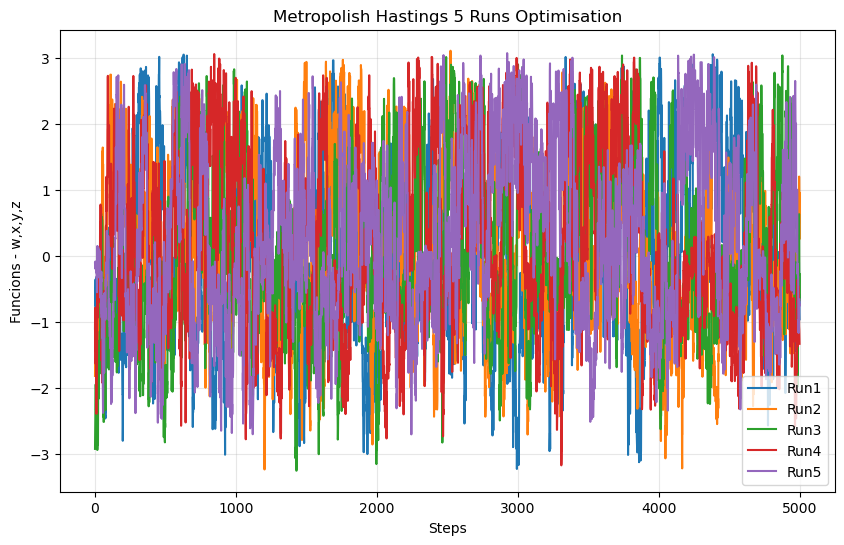

------------------------------
Run 1: max f = 3.0488
final position (w,x,y,z) = [ 3.4     3.0195  2.6447 -2.7849]

Run 2: max f = 3.1027
final position (w,x,y,z) = [-1.6563  0.9927  3.0678 -2.4606]

Run 3: max f = 3.0313
final position (w,x,y,z) = [-2.0393  2.5934  0.7958  0.275 ]

Run 4: max f = 3.0526
final position (w,x,y,z) = [-0.9676  1.6571  0.4076  0.2541]

Run 5: max f = 3.0661
final position (w,x,y,z) = [ 3.0588 -0.3782 -2.4531 -1.1947]



In [28]:
# Correct code to accept worse moves

def metropolis_hastings(f, x_init, sigma=0.5, n_steps=2000):
    x_current = x_init
    f_current = f(*x_current)
    history = [f_current]

    for l in range(n_steps):
        x_proposal = x_current + np.random.normal \
        (0, sigma, size=4)
        x_proposal = np.clip(x_proposal, -3.5, 3.5)#domain given
        f_proposal = f(*x_proposal)

        # Acceptance rule amended 
        # (accept better moves and sometimes the worse too)
        if f_proposal > f_current or np.random.rand() \
        < np.exp(f_proposal - f_current):
            x_current = x_proposal
            f_current = f_proposal

        history.append(f_current)

    return x_current, history


# Simulations (different starting points and seeds)
results = []
plt.figure(figsize=(10,6))

for seed in range(5):
    np.random.seed(seed)
    # random starting positions 
    x_init = np.random.uniform(-3.5, 3.5, size=4)#random w, x, y z
    final_x, history = metropolis_hastings \
    (f, x_init, sigma=0.5, n_steps=5000)

    results.append((final_x, max(history)))
    plt.plot(history, label=f'Run{seed+1}')

# Plots
plt.xlabel("Steps")
plt.ylabel("Funcions - w,x,y,z")
plt.title("Metropolish Hastings 5 Runs Optimisation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print max and final position for every single run  
print("-" * 30)
for i, (pos, max_val) in enumerate(results):
    print(f"Run {i+1}: max f = {max_val:.4f}")
    print(f"final position (w,x,y,z) = {np.round(pos, 4)}\n")
    

Above there are 5 run using the Metropolis Hastings algorithm beginning at a different starting point every single time. 
The output max f shows the highest number in the function that the run managed to hit. 
The line w, x, y, z shows the final position of the algorithm.
The outcomes show similar results as the five runs had similar maximum values (there being between 3.03 and 3.10), but it is also important to note that the final positions are different. 
To interpret, this informs me that the function finds points with similar high values but given its randomness, the alghorithm finishes in different locations in its 4D space after every single run.

### (II) Do all runs converge to the same maximum? If not, what does this tell you about the algorithm or the function? ###

No, as shown above, not all runs converse to the exact same final position (peak) or maximum. This means that the algorithm shows multiple high local maxima and the starting point of the funcion is important as the randomness and starting point affect the maximum of the chain final point.

### (III) Calculate the acceptance ratio for each run. Are they similar? ###

In [31]:
#Metropolis Hastings function (with acceptance counter)
def metropolis_hastings(f, x_init, sigma=0.5, n_steps=5000):
    x_current = x_init
    f_current = f(*x_current)
    accepts = 0

    for w in range(n_steps):
        x_proposal = x_current + \
        np.random.normal(0, sigma, size=4)
        x_proposal = np.clip(x_proposal, -3.5, 3.5) 
        f_proposal = f(*x_proposal)

        if f_proposal > f_current or np.random.rand() \
        < np.exp(f_proposal - f_current):
            x_current = x_proposal
            f_current = f_proposal
            accepts = accepts + 1

    acceptance_ratio = accepts / n_steps  #Fractions for accepted moves
    return x_current, acceptance_ratio    #return final positions and ratio acceptance

#Run 5 Times and show acceptane ratios 
for seed in range(5):
    np.random.seed(seed)  #compute seeds to replicate
    x_init = np.random.uniform \
    (-3.5,3.5, size = 4) #starting positions
    _, acc_ratio = metropolis_hastings \
    (f, x_init, sigma=0.5, n_steps=5000)
    print(f"Run {seed+1}: acceptance ratio = {acc_ratio:.3f}")

Run 1: acceptance ratio = 0.813
Run 2: acceptance ratio = 0.795
Run 3: acceptance ratio = 0.801
Run 4: acceptance ratio = 0.795
Run 5: acceptance ratio = 0.791


The 5 acceptance ratios above are computed by divinding the accepted number of moves by the total number of steps. The five ratios presented, namely 0.813, 0.795, 0.801, 0.795, 0.791 are all very similar to 0.8. This illustrates that the function is performing in a consistent manner with the 0.5 standard deviation.

### (III) What do you estimate your maximum value of f() to be in the given range? Where is the maximum located? ###

Looking at the Question 4(I), the maximum value identified was f=3.1027, specifically in run 2 roughly at point (w, x, y, z) = (-1.66, 0.99, 3.07, -2.46). This is the estimated maximum and location in the range analysed.

## (d) You’ve found a maximum, but how confident are you it’s the global maximum and not just a local one? How might you verify you found the global maximum? ##

I cannot be very confident that this is the GLOBAL maximum value because the five runs performed above identified different positions and values. This means that the alghorithm is multimodal or in other words that it has different hills. 
In order to verify the global maximum, I would:

- Do more runs: instead of doing it for 5 times, I would run it for 300 / 500 / 1000 times. This gives the function more time to find higher slopes.
- Alter the standard deviation: at the moment, the standard deviation set is 0.5, which can be a bit too small. This means that the alghorithm only makes really tiny steps to the nearby hill. If I amended it to 1, the function will do bigger steps / jumps which would hopefully lead into identifying taller peaks.

In [32]:
!pip install -q nbconvert[webpdf]
!jupyter nbconvert "MATPMD4_Assignment1_3541011.ipynb" \
--to webpdf --allow-chromium-download

[NbConvertApp] Converting notebook MATPMD4_Assignment1_3541011.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 517525 bytes to MATPMD4_Assignment1_3541011.pdf
